# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 47     |  |
| :-------------|:-------------|
| Matteo Leonardi | 6391494 |
| Roosmarijn Kos | 6460097 |
| John Sia | 6223494 |
| Planning Groep: 47     |Tijdstip / Tijdspanne  |
|---|---|
| een condensator gemaakt en getest | 12:30 |
| pauze 1 | 12:30 - 13:30 |
| sensor ontworpen en gebouwd | 15:00 |
| pauze 2 | 15:00 - 15:15 |
| sensor gekalibreert | 16:00 |
| opruimen | 16:00 - ... |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="tudelftLogo.png" alt="schets student 1" width="400"/>

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [ ]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
epsilon0 = 8.8541878188e-12

def vlakkeplaat(epsilonrel, A, d):
    C = epsilon0 * epsilonrel * A / d
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [22]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

epsilonrel_karton = 2  # ruwe schatting, foutmarge van 1
A = 0.01  # m^2, oppervlakte van onze twee platen
d = 1*0.001  # meter, de afstand tussen de platen, de dikte van het karton

C_voorspelling = vlakkeplaat(epsilonrel_karton, A, d)

print(f"Berekende capaciteit plaatcondensator groep 47 is {C_voorspelling*10**12:.1f} pF")



Berekende capaciteit plaatcondensator groep 47 is 177.1 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](tudelftLogo.png)
![scope meting 2](tudelftLogo.png)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep XX| ? |? | ? |? |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](schets_3_sensoren.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die draaisnelheid meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](tudelftLogo.png)

In [ ]:
# variabelen maken
V_in = 16  # volt
f = 1e3  # frequentie
R = 1e3  # ohm
A = 0.01  # m^2
d = 1*0.001  # meter
L0 = 3.85*0.01  # meter
A0 = A  # de oppervlakt als de twee platen volledig overlappen

# functies maken
def capaciteit_meten(V_out):  # functie om meetwaarden om te zetten naar capaciteit
    global V_in, R, f
    return V_out/(R*V_in*2*np.pi*f)

def overlappende_oppervlakte(alpha):
    global A0
    while np.max(alpha) > np.pi/2:
        alpha = np.where(alpha > np.pi/2, alpha-np.pi/2, alpha)
    
    oppervlakte_1_driehoek = (25*np.sin(2*alpha))/(np.sin(alpha)+np.cos(alpha)+1)**2
    return A0 - 8*(oppervlakte_1_driehoek*0.0001)

def vlakkeplaat(A, epsilonrel):
    global d
    C = epsilon0 * epsilonrel * A / d
    return C

def c_in_functie_van_alpha(alpha, epsilonrel):
    return vlakkeplaat(overlappende_oppervlakte(alpha), epsilonrel)

In de volgende grafiek schetsen we het verband dat we verwachten.


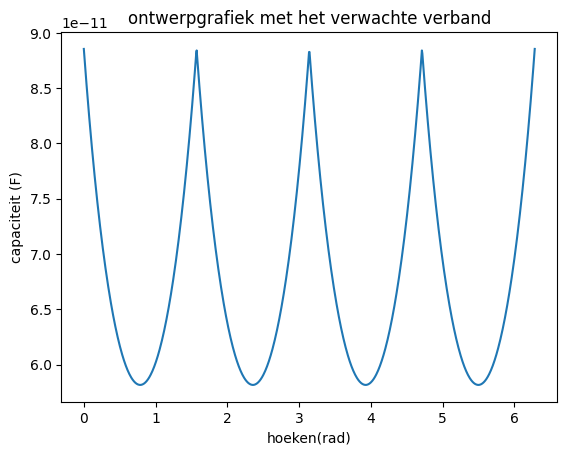

In [49]:
# ontwerpgrafiek
print('In de volgende grafiek schetsen we het verband dat we verwachten.')

hoeken = np.linspace(0, 2*np.pi, 1000)
oppervlakten = overlappende_oppervlakte(hoeken)
capaciteit = vlakkeplaat(oppervlakten, 1)

plt.figure(dpi=100)
plt.title('ontwerpgrafiek met het verwachte verband')

plt.plot(hoeken, capaciteit)

plt.xlabel('hoeken(rad)')
plt.ylabel('capaciteit (F)')

plt.show()

In [ ]:

V_out = np.array([...])
hoeken = np.array([...])
fit_hoeken = np.linspace(np.min(hoeken), np.max(hoeken), 10000)   # veel hoeken voor een gladde fit

C = capaciteit_meten(V_out)

opt, cov = curve_fit(c_in_functie_van_alpha, hoeken, C)

plt.figure(dpi=300)
plt.title('analyse van draaiende platen van een condensator')

plt.scatter(hoeken, C, s=1, color='blue', label='data')
plt.plot(fit_hoeken, c_in_functie_van_alpha(fit_hoeken, *opt), color='green', label='fit')

plt.xlabel('hoek (rad)')
plt.ylabel('capaciteit (F)')

plt.legend()
plt.tight_layout()
plt.show()

TypeError: unsupported operand type(s) for /: 'ellipsis' and 'float'

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 50pF | 0.25V |
| gemiddelde capaciteit| 100pF | 1.00V |
| maximale capaciteit| 200pF | 1.92V |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](tudelftLogo.png)
![meting 2](tudelftLogo.png)

## Opdracht 7: Plot de kalibratiegrafiek.

In [4]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* verbetering 1
* verbetering 2

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](tudelftLogo.png)

In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

## Opdracht 10: Vul hieronder de conclusie in.

Vul hier de conclusie in

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.